In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split



In [2]:
raw_data = pd.read_csv("./crx.data", header=None, na_values="?")

cont_attr = [1, 2, 7, 10, 13, 14]

for col in range(16):
    if col in cont_attr:
        _mean = raw_data[col].mean()
        raw_data[col] = raw_data[col].fillna(_mean)
    else:
        _mode = raw_data[col].mode()[0]
        raw_data[col] = raw_data[col].fillna(_mode)

print(raw_data.isna().sum())


min_max_scaler = MinMaxScaler()
x = raw_data[cont_attr].values
x_scaled = min_max_scaler.fit_transform(x)

normalized = pd.DataFrame(x_scaled, columns=cont_attr, index=raw_data.index)
raw_data[cont_attr] = normalized


ord_enc = OrdinalEncoder(dtype = np.int32)
raw_data[15] = ord_enc.fit_transform(raw_data[[15]])

dis_attr = [0, 3, 4, 5, 6, 8, 9, 11, 12]
one_hat = pd.get_dummies(raw_data[dis_attr], dtype=int)
raw_data = raw_data.drop(dis_attr, axis = 1)
X = raw_data.join(one_hat)

Y = np.array(X.pop(15))
X = np.array(X)
print(X.shape, Y.shape)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)
print(X_test.shape, Y_test.shape)

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
dtype: int64
(690, 46) (690,)
(138, 46) (138,)


In [3]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, Y_train)
score = knn.score(X_test, Y_test)

list_of_score = []
for index in range(1,21):
    _knn = KNeighborsClassifier(n_neighbors=index)
    _knn.fit(X_train, Y_train)
    _score = _knn.score(X_test, Y_test)
    list_of_score.append(_score)


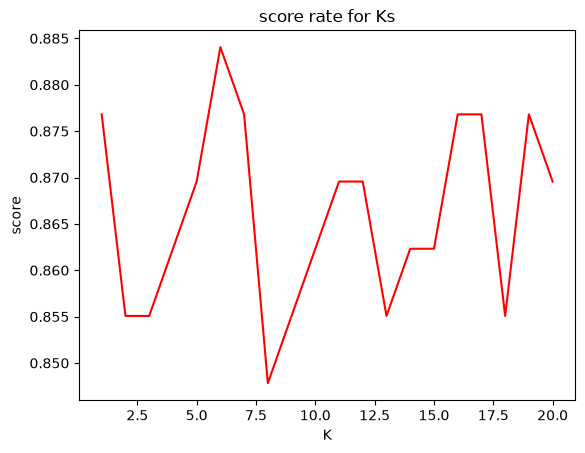

In [4]:
plt.plot(list(range(1,21)),list_of_score,color="red")
plt.xlabel("K")
plt.ylabel("score")
plt.title("score rate for Ks")
plt.show()

In [5]:
scores = np.array(list_of_score)
max_index = np.argmax(scores) + 1
print(max_index)

6
